<a href="https://colab.research.google.com/github/Swarooprewatkar/data-science-case-studies/blob/main/CaseStudies/NetflixAnalysis/netflix_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.style.use('ggplot')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12,6)

In [3]:
df = pd.read_csv("sample_data/netflix_titles.csv")

In [4]:
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
if df.duplicated().sum() > 0: #
    print("Duplicate exists")
else:
    print("Doesn't Exist")

Doesn't Exist


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df['country'] = df['country'].fillna("Unknown")
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Unknown")

In [9]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [11]:
# Feature engineering
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [12]:
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_4955/710516317.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)


In [13]:
df['duration_type'] = df['duration'].str.extract('([a-zA-Z]+)')

In [14]:
type_counts = df['type'].value_counts()

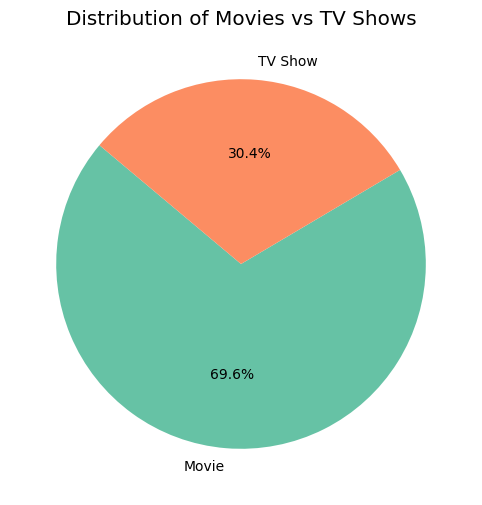

In [15]:
plt.figure()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Distribution of Movies vs TV Shows")
plt.show()

In [16]:
growth = df.groupby('year_added').size()

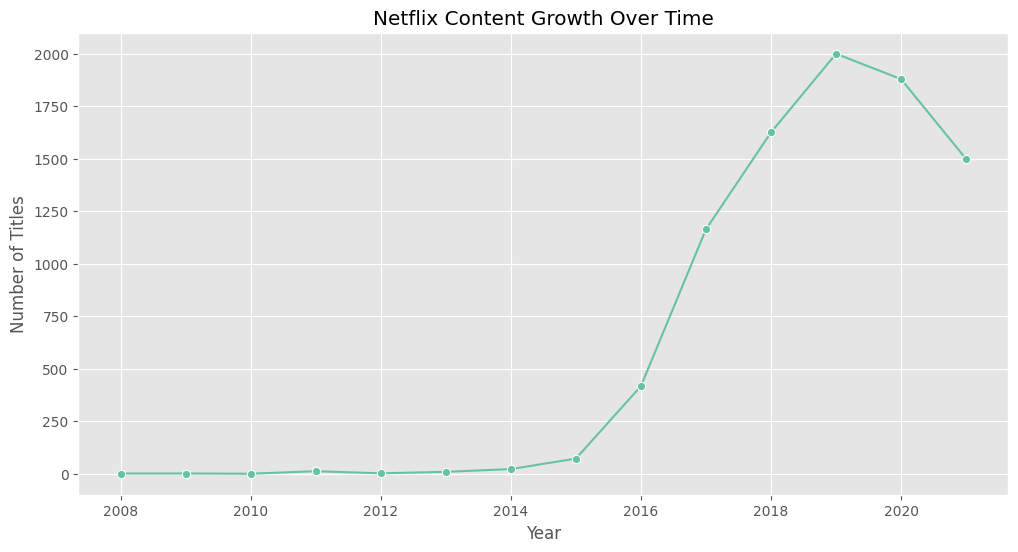

In [17]:
sns.lineplot(x=growth.index, y=growth.values, marker='o')
plt.title("Netflix Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

In [18]:
country_df = df['country'].str.split(', ').explode()
top_countries = country_df.value_counts().head(10)

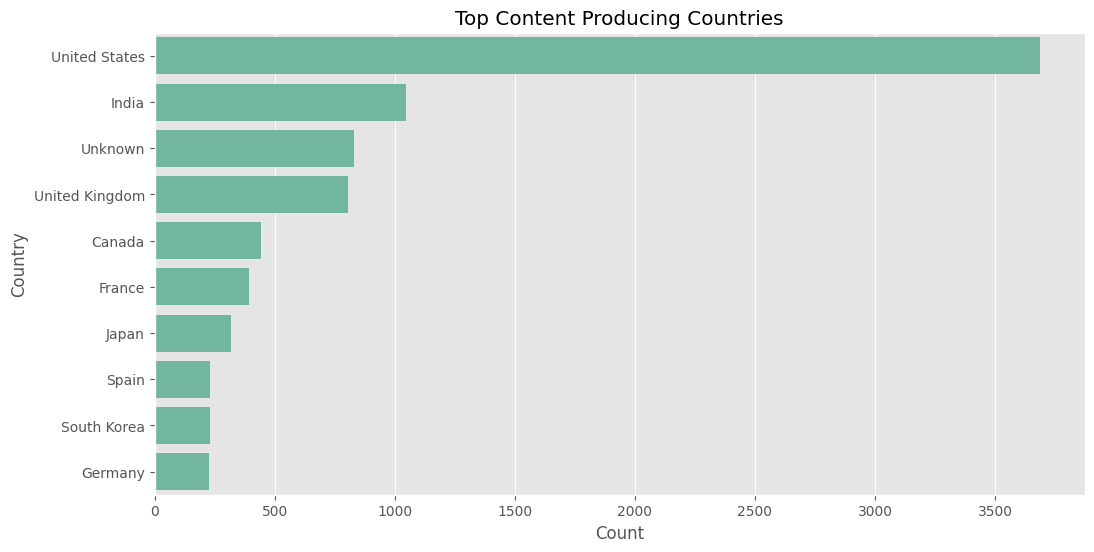

In [19]:
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top Content Producing Countries")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

In [20]:
genre_df = df['listed_in'].str.split(', ').explode()
top_genres = genre_df.value_counts().head(10)

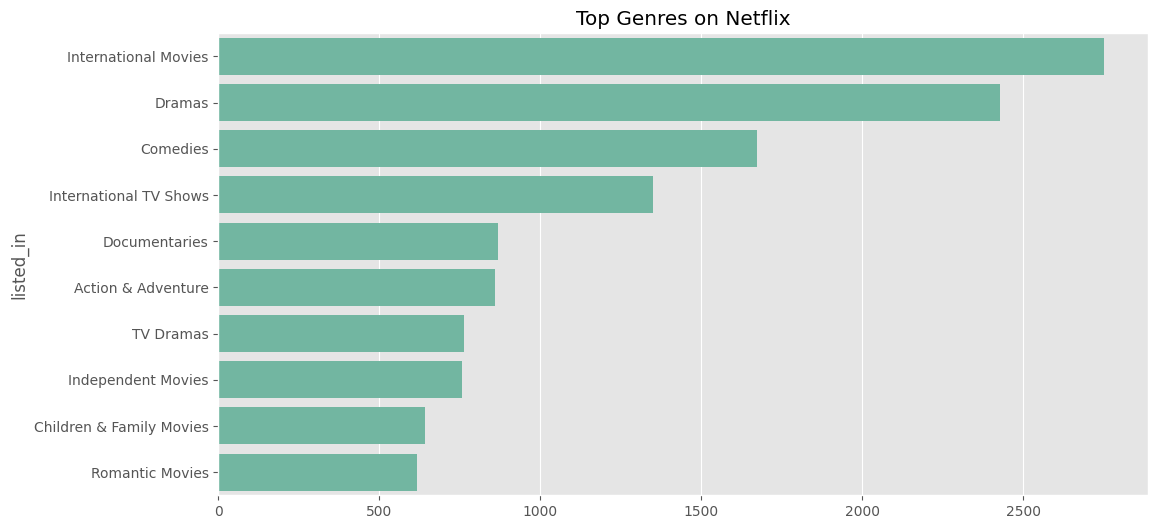

In [21]:
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top Genres on Netflix")
plt.show()

In [22]:
pivot = df.pivot_table(index='type', columns='year_added', aggfunc='size')

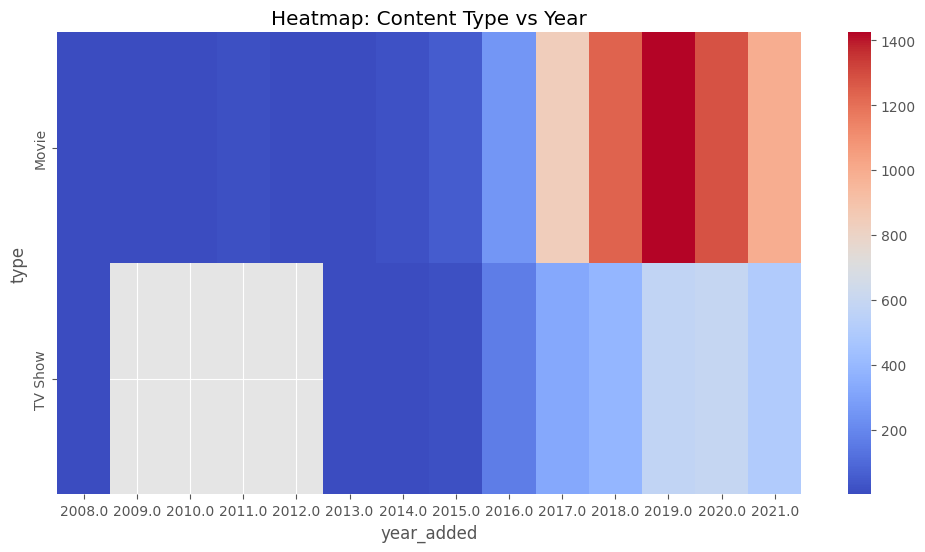

In [23]:
sns.heatmap(pivot, cmap='coolwarm')
plt.title("Heatmap: Content Type vs Year")
plt.show()

In [24]:
movies = df[df['type'] == 'Movie']

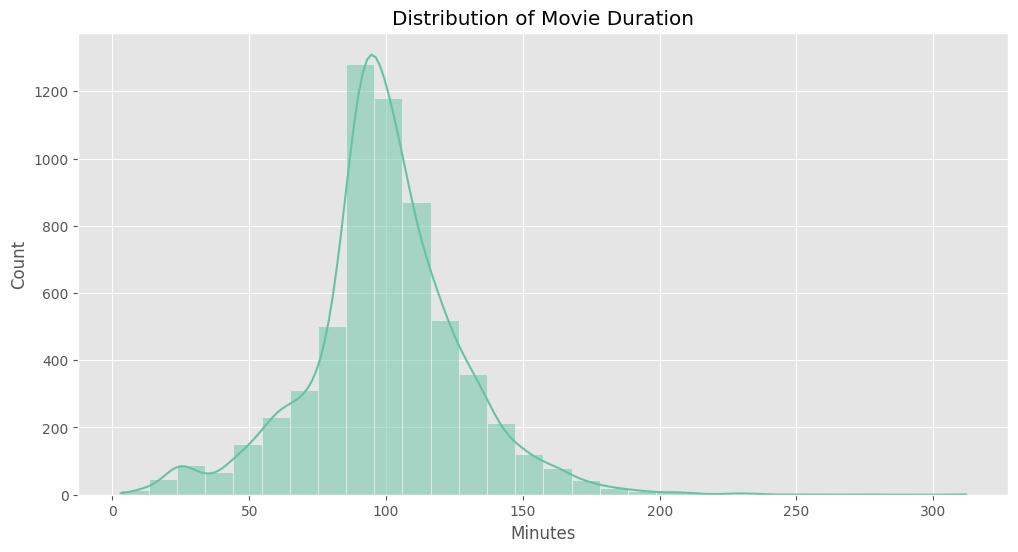

In [25]:
sns.histplot(movies['duration_num'], bins=30, kde=True)
plt.title("Distribution of Movie Duration")
plt.xlabel("Minutes")
plt.show()

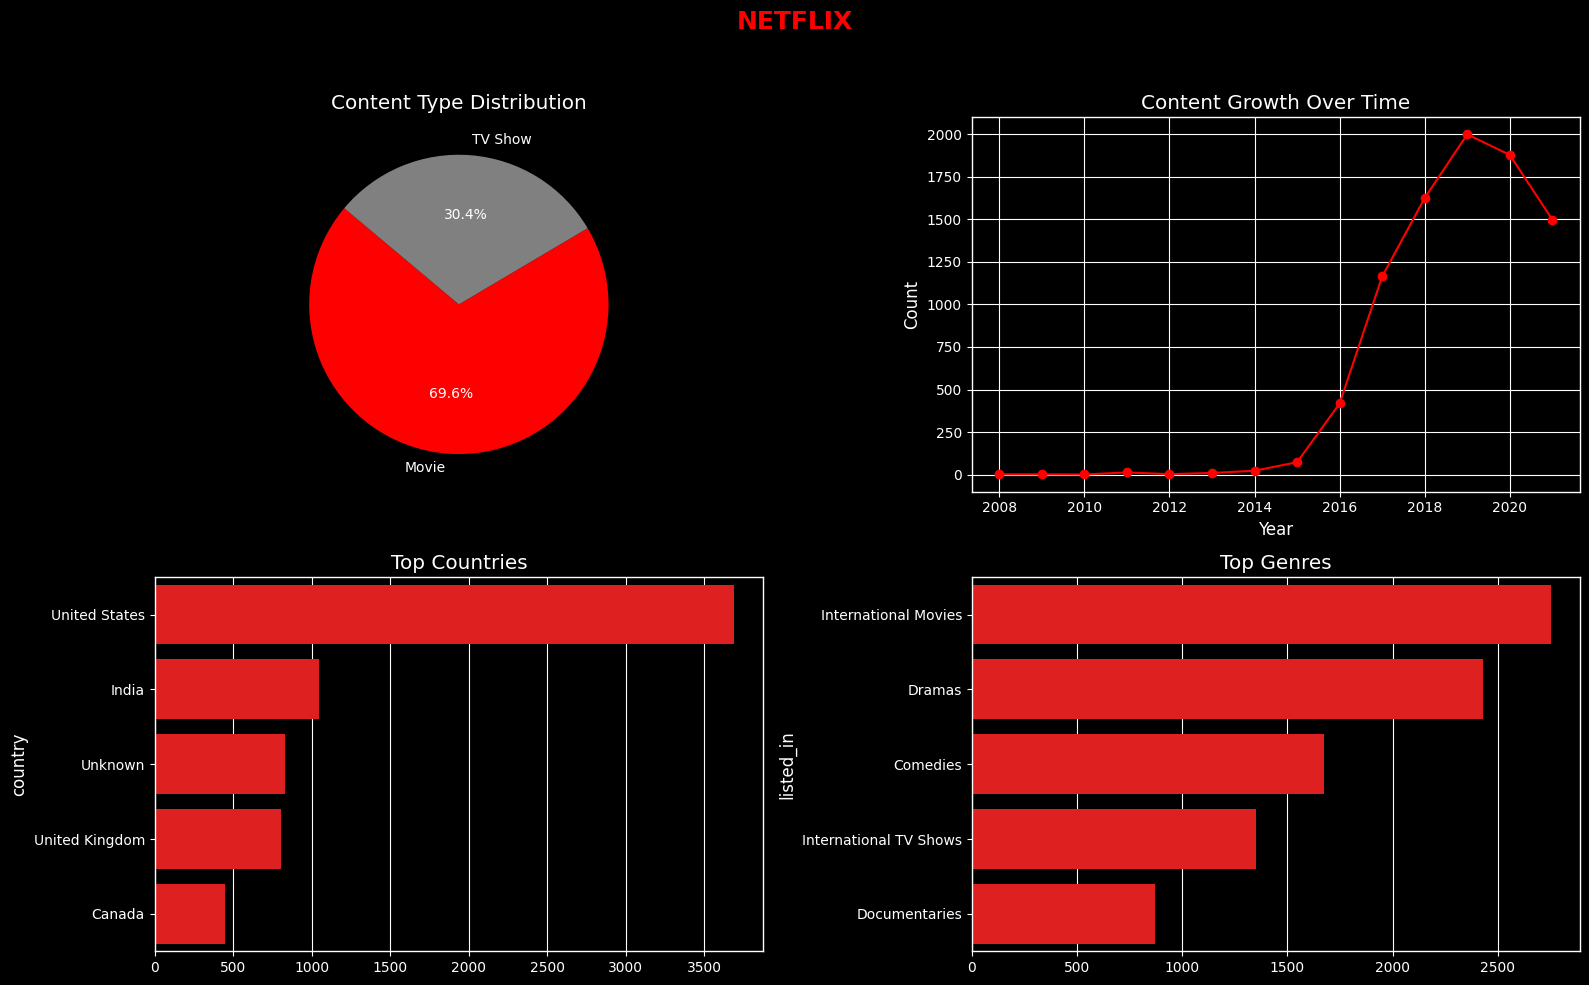

In [31]:
country_df = df['country'].str.split(', ').explode()
genre_df = df['listed_in'].str.split(', ').explode()

type_counts = df['type'].value_counts()
growth = df.groupby('year_added').size()
top_countries = country_df.value_counts().head(5)
top_genres = genre_df.value_counts().head(5)

plt.style.use("dark_background")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("NETFLIX", fontsize=18, color='red', fontweight='bold')

axes[0,0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
              colors=['red', 'gray'], startangle=140)
axes[0,0].set_title("Content Type Distribution", color='white')

axes[0,1].plot(growth.index, growth.values, marker='o', color='red')
axes[0,1].set_title("Content Growth Over Time", color='white')
axes[0,1].set_xlabel("Year")
axes[0,1].set_ylabel("Count")

sns.barplot(x=top_countries.values, y=top_countries.index,
            ax=axes[1,0], color='red')
axes[1,0].set_title("Top Countries", color='white')

sns.barplot(x=top_genres.values, y=top_genres.index,
            ax=axes[1,1], color='red')
axes[1,1].set_title("Top Genres", color='white')

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

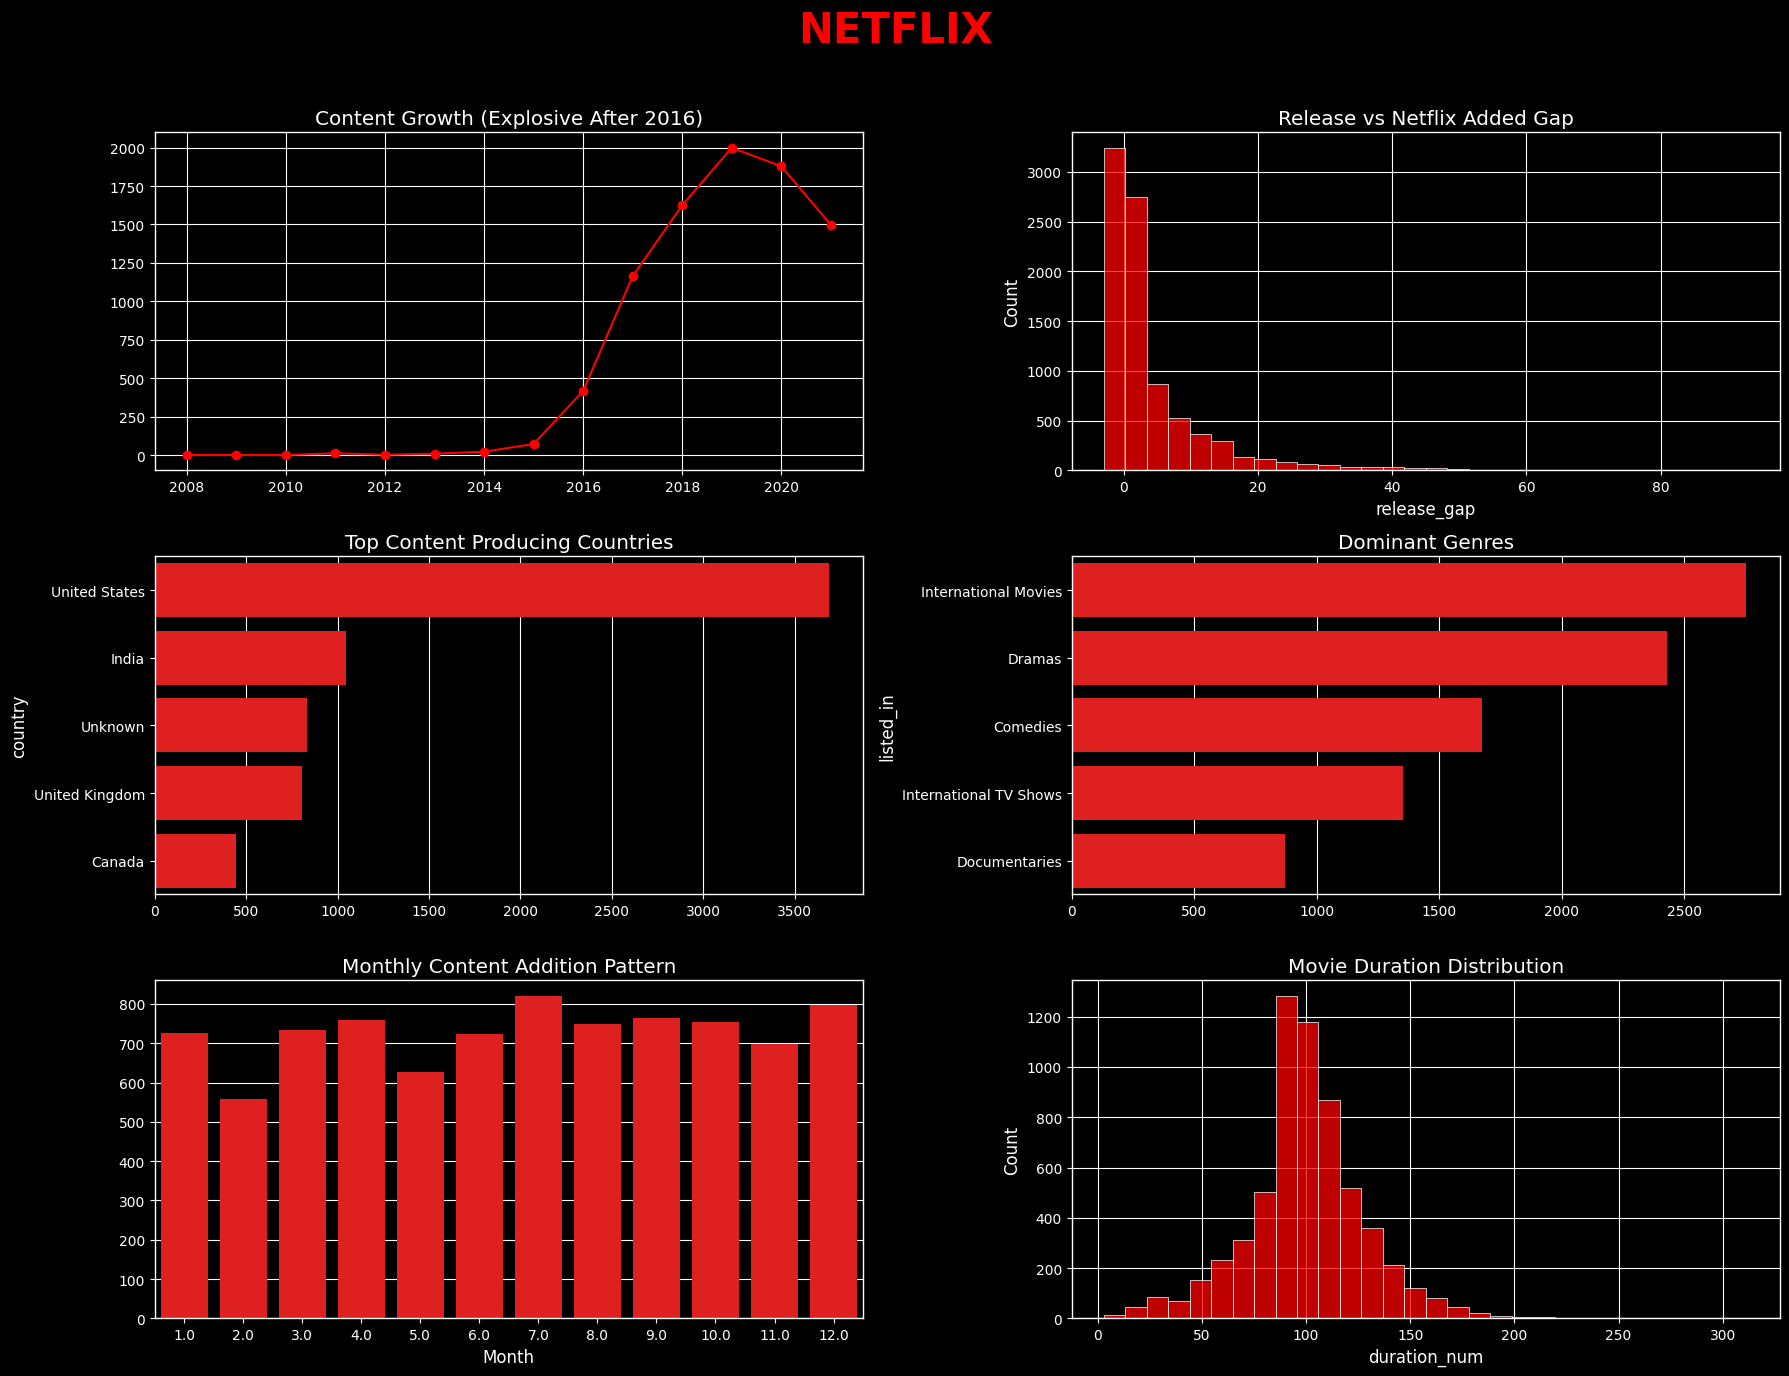

In [32]:
growth = df.groupby('year_added').size()

df['release_gap'] = df['year_added'] - df['release_year']

monthly = df['month_added'].value_counts().sort_index()

movies = df[df['type'] == 'Movie']

plt.style.use("dark_background")

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.suptitle("NETFLIX", fontsize=30, color='red', fontweight='bold')

axes[0,0].plot(growth.index, growth.values, marker='o', color='red')
axes[0,0].set_title("Content Growth (Explosive After 2016)", color='white')

sns.histplot(df['release_gap'].dropna(), bins=30, ax=axes[0,1], color='red')
axes[0,1].set_title("Release vs Netflix Added Gap", color='white')

sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[1,0], color='red')
axes[1,0].set_title("Top Content Producing Countries", color='white')

sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[1,1], color='red')
axes[1,1].set_title("Dominant Genres", color='white')

sns.barplot(x=monthly.index, y=monthly.values, ax=axes[2,0], color='red')
axes[2,0].set_title("Monthly Content Addition Pattern", color='white')
axes[2,0].set_xlabel("Month")

sns.histplot(movies['duration_num'], bins=30, ax=axes[2,1], color='red')
axes[2,1].set_title("Movie Duration Distribution", color='white')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()